# **Inteligencia Artificial – Sistemas Inteligentes: Trabajo de Laboratorio N° 1**

*   **Integrantes:**   
Demarchi Sofia - 42991142   
Garau Maria Micaela - 44572286  
Giuffrida Lucia - 43153767  
Gonzalez Houriet Selena - 44122177  
Gorordo Constanza  
Lugones Lautaro  
Trachta Agustin - 43271890  
Vasquez Francisco Javier - 43812221
*   **Grupo N°:** 2
*   **Dataset:** Titanic - Machine Learning from Disaster (Kaggle)
*   **Link al Colab:**

---

## **Finalidad del Laboratorio**
Este trabajo tiene como objetivo aplicar los conceptos fundamentales de Data Science y Machine Learning para resolver un problema de clasificación supervisada. Se seguirán los procedimientos de un proceso KDD (Knowledge Discovery in Databases), desde la exploración y preprocesamiento de los datos hasta el entrenamiento, evaluación y comparación de diferentes modelos de Aprendizaje Automático.

---

### **Paso 0: Configuración del Entorno e Importación de Librerías**

Antes de comenzar, importamos todas las librerías que utilizaremos a lo largo del proyecto. Cada una tiene un propósito específico:
*   **Pandas:** Para la manipulación y análisis de datos en formato de tablas (DataFrames).
*   **NumPy:** Para operaciones numéricas eficientes, especialmente con arreglos.
*   **Matplotlib y Seaborn:** Para la visualización de datos y la creación de gráficos.
*   **Scikit-learn:** La librería fundamental para implementar los modelos de Machine Learning, métricas de evaluación y herramientas de preprocesamiento.

In [ ]:
# Importación de librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de modelos de Scikit-learn
from sklearn.model_selection import train_test_split # Particiona datos en entrenamiento y prueba
from sklearn.tree import DecisionTreeClassifier # Árbol de decisión para clasificación.
from sklearn.ensemble import RandomForestClassifier # Ensamble de muchos árboles (bagging). para rendimiento
from sklearn.cluster import KMeans # Clustering no supervisado por centroides.

# Importación de métricas y herramientas de preprocesamiento
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler # Estandarización (media 0, desvío 1).
from sklearn import tree # Submódulo con utilidades de árboles (por ej. visualización).

# Configuraciones para una mejor visualización
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

---
### **Paso 1: Adquisición y Análisis Exploratorio de Datos (EDA)**

Esta es la primera etapa del proceso KDD. Cargamos el dataset y realizamos un análisis exhaustivo para entender su estructura, la calidad de los datos y las relaciones entre las variables.

**1.1. Carga de los Datos**

Usaremos Pandas para cargar los datos desde un archivo CSV. Kaggle proporciona dos archivos: `train.csv` (con etiquetas, para entrenar) y `test.csv` (sin etiquetas, para la competencia). Usaremos `train.csv` para todo nuestro análisis y modelado.

In [ ]:
# Cargar el dataset de entrenamiento desde una URL pública (para que sea reproducible)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df_titanic = pd.read_csv(url)

# Mostrar las primeras 5 filas para tener una vista inicial
print("Primeras 5 filas del dataset:")
display(df_titanic.head())

# Mostrar información general del DataFrame
print("\nInformación general y tipos de datos:")
df_titanic.info()

# Resumen estadístico de las columnas numéricas
print("\nResumen estadístico:")
display(df_titanic.describe())

# Conteo de valores nulos por columna
print("\nConteo de valores nulos:")
print(df_titanic.isnull().sum())

Primeras 5 filas del dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Resumen estadístico:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Conteo de valores nulos:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Observaciones Iniciales:**
*   El dataset tiene 891 registros y 12 columnas.
*   Hay valores nulos en `Age` (177), `Cabin` (687) y `Embarked` (2). Estos deberán ser tratados.
*   La variable objetivo es `Survived` (0 = No, 1 = Sí).
*   Hay variables categóricas (`Sex`, `Embarked`) y numéricas (`Age`, `Fare`). `Cabin` y `Ticket` son alfanuméricas.

**1.2. Visualización de Datos**

Las visualizaciones nos ayudan a entender mejor las relaciones entre las variables y la variable objetivo (`Survived`).


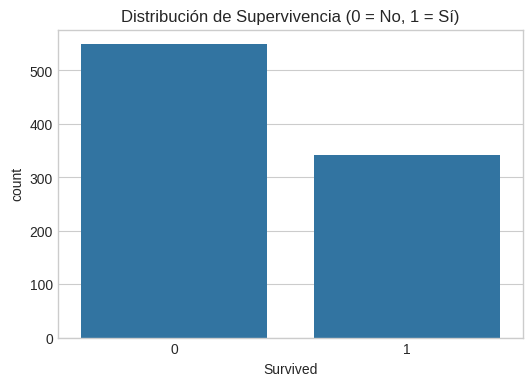

Tasa de supervivencia: 38.38%


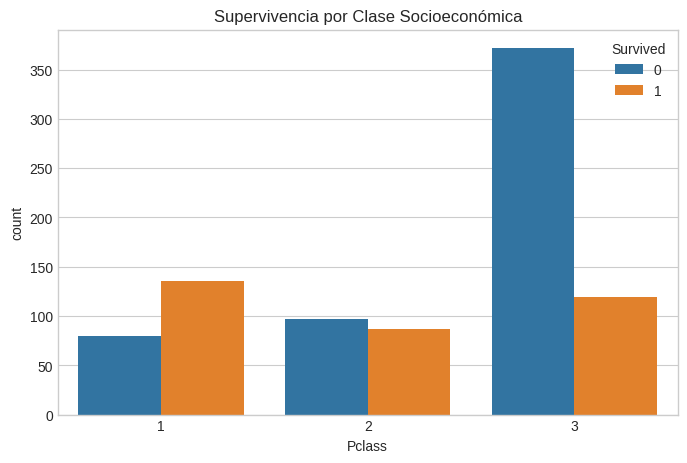

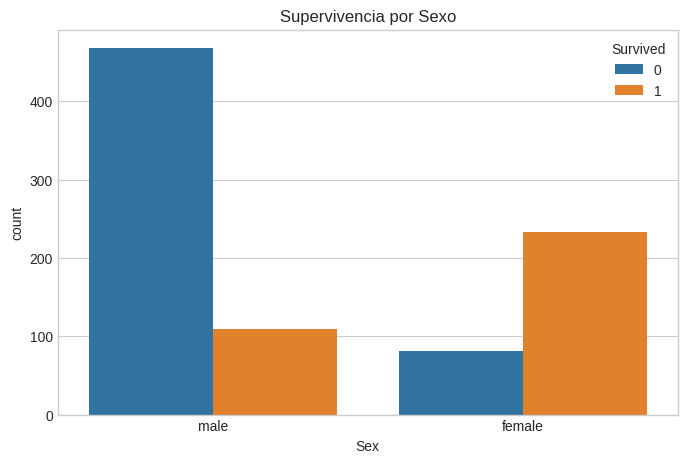

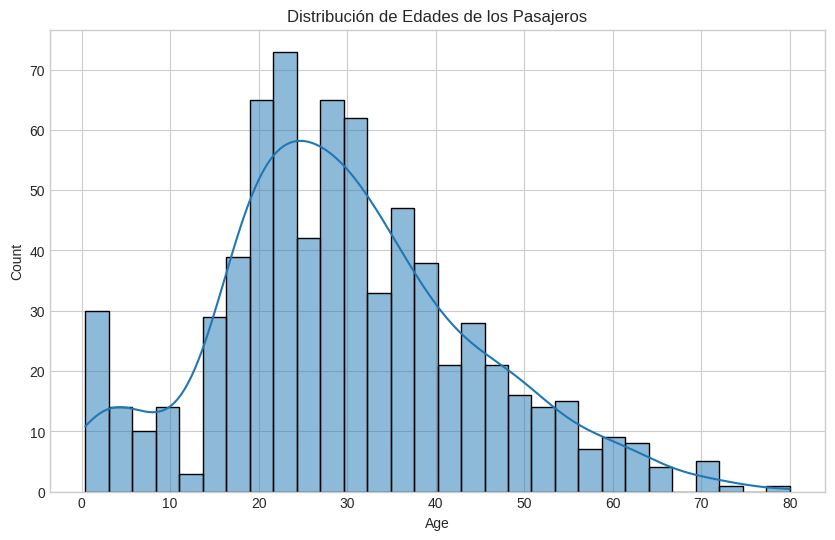

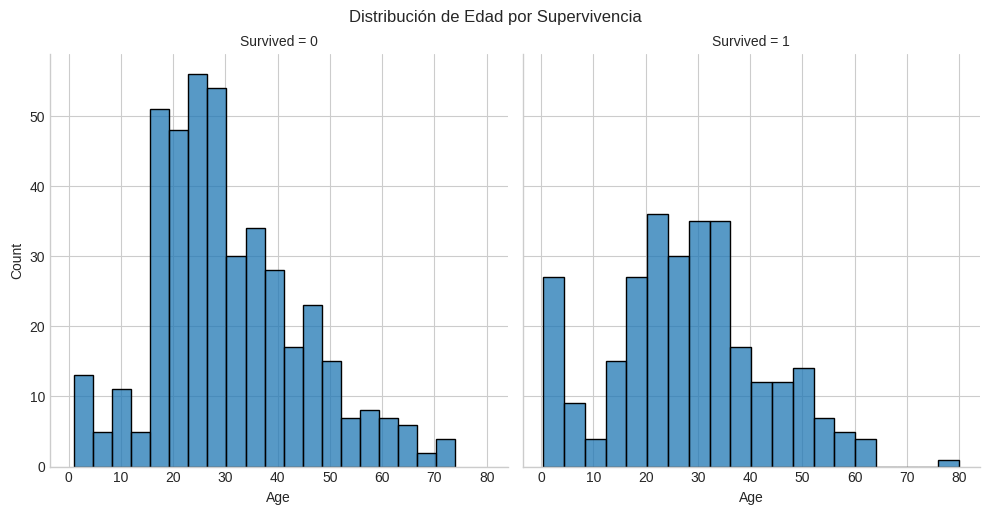

In [ ]:
# Gráfico 1: Tasa de Supervivencia General
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df_titanic)
plt.title('Distribución de Supervivencia (0 = No, 1 = Sí)')
plt.show()
print(f"Tasa de supervivencia: {df_titanic['Survived'].mean()*100:.2f}%")


# Gráfico 2: Supervivencia por Clase (Pclass)
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', hue='Survived', data=df_titanic)
plt.title('Supervivencia por Clase Socioeconómica')
plt.show()

# Gráfico 3: Supervivencia por Sexo
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='Survived', data=df_titanic)
plt.title('Supervivencia por Sexo')
plt.show()

# Gráfico 4: Distribución de Edad
plt.figure(figsize=(10, 6))
sns.histplot(df_titanic['Age'].dropna(), kde=True, bins=30)
plt.title('Distribución de Edades de los Pasajeros')
plt.show()

# Gráfico 5: Supervivencia por Edad
g = sns.FacetGrid(df_titanic, col='Survived', height=5)
g.map(sns.histplot, 'Age', bins=20, kde=False)
plt.suptitle('Distribución de Edad por Supervivencia', y=1.02)
plt.show()

**Conclusiones del EDA:**
1.  **Clase Social (`Pclass`):** Los pasajeros de primera clase tuvieron una tasa de supervivencia mucho mayor que los de tercera clase.
2.  **Sexo (`Sex`):** Las mujeres tuvieron una tasa de supervivencia significativamente más alta que los hombres, reflejando el protocolo "mujeres y niños primero".
3.  **Edad (`Age`):** Los niños pequeños tuvieron una mayor probabilidad de sobrevivir. Hay un gran número de pasajeros entre 20 y 40 años que no sobrevivieron.

---
### **Paso 2: Preprocesamiento y Limpieza de Datos**

Para que los modelos puedan procesar los datos, necesitamos limpiar los valores nulos y convertir las variables categóricas en numéricas.

In [ ]:
# Copiamos el dataframe para no modificar el original
df_procesado = df_titanic.copy()

# 1. Manejo de valores nulos en 'Age'
# Usaremos la mediana para imputar los valores faltantes, ya que es más robusta a outliers que la media.
median_age = df_procesado['Age'].median()
df_procesado['Age'].fillna(median_age, inplace=True)
print(f"Valores nulos en 'Age' imputados con la mediana: {median_age}")

# 2. Manejo de valores nulos en 'Embarked'
# Usaremos la moda (el valor más frecuente) para los 2 valores faltantes.
mode_embarked = df_procesado['Embarked'].mode()[0]
df_procesado['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Valores nulos en 'Embarked' imputados con la moda: {mode_embarked}")

# 3. Manejo de valores nulos en 'Cabin'
# Hay demasiados valores nulos (687 de 891). En lugar de eliminar la columna,
# crearemos una nueva variable binaria que indique si el pasajero tenía una cabina asignada o no.
df_procesado['Has_Cabin'] = df_procesado['Cabin'].apply(lambda x: 0 if type(x) == float else 1)

# 4. Eliminación de columnas innecesarias
# 'Ticket', 'Cabin' y 'Name' son demasiado específicas para este análisis inicial y no aportan valor predictivo general.
# 'PassengerId' es solo un identificador.
df_procesado = df_procesado.drop(['Ticket', 'Cabin', 'Name', 'PassengerId'], axis=1)

# 5. Conversión de variables categóricas a numéricas
# Usaremos One-Hot Encoding para 'Sex' y 'Embarked'.
df_procesado = pd.get_dummies(df_procesado, columns=['Sex', 'Embarked'], drop_first=True)

print("\nDataset después del preprocesamiento:")
display(df_procesado.head())
print("\nVerificación de valores nulos restantes:")
print(df_procesado.isnull().sum())

Valores nulos en 'Age' imputados con la mediana: 28.0
Valores nulos en 'Embarked' imputados con la moda: S

Dataset después del preprocesamiento:


,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,False,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True
3,1,1,35.0,1,0,53.1000,1,False,False,True
4,0,3,35.0,0,0,8.0500,0,True,False,True



Verificación de valores nulos restantes:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Has_Cabin     0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


### **Paso 3: Partición del Dataset para Entrenamiento y Testeo**

Ahora, dividimos nuestro dataset en dos conjuntos: uno para **entrenar** el modelo y otro para **testear** su rendimiento con datos que no ha visto antes.

 La librería `scikit-learn` proporciona una función muy útil llamada `train_test_split` que genera esta partición de manera aleatoria y estratificada, asegurando que la proporción de supervivientes y no supervivientes sea similar en ambos conjuntos.

*   `X`: El DataFrame con todas las variables predictoras (features).
*   `y`: La serie con la variable objetivo (`Survived`).
*   `test_size=0.2`: Especifica que el 20% de los datos se usará para el conjunto de testeo.
*   `random_state=42`: Fija una "semilla" para la aleatoriedad, lo que garantiza que la división sea siempre la misma si se ejecuta el código de nuevo. Esto es crucial para la reproducibilidad de los resultados.
*   `stratify=y`: Asegura que la proporción de supervivientes sea la misma en el conjunto de entrenamiento y de testeo.

In [ ]:
# Separar las características (X) de la variable objetivo (y)
X = df_procesado.drop('Survived', axis=1)
y = df_procesado['Survived']

# Dividir los datos en 80% para entrenamiento y 20% para testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} registros")
print(f"Tamaño del conjunto de testeo: {X_test.shape[0]} registros")

Tamaño del conjunto de entrenamiento: 712 registros
Tamaño del conjunto de testeo: 179 registros


---
### **Paso 4: Entrenamiento y Evaluación de Modelos de Aprendizaje Supervisado**

En esta fase central del laboratorio, se procede al entrenamiento, validación y evaluación de dos arquitecturas de modelos de aprendizaje supervisado. El objetivo es comparar un modelo intrínsecamente interpretable, el Árbol de Decisión (CART), con un modelo de ensamble de alto rendimiento, el Random Forest, para analizar el compromiso existente entre la interpretabilidad y la precisión predictiva.

---
#### **4.1. Modelo 1: Árbol de Decisión (CART) - Arquitectura Interpretable**

**Fundamento Teórico:**
El algoritmo de Árbol de Decisión, y específicamente la implementación CART (Classification and Regression Trees), construye un modelo predictivo a través de una estructura jerárquica de nodos. El proceso, conocido como particionamiento recursivo, selecciona en cada nodo la característica y el umbral que optimizan una métrica de impureza, como el **Índice de Gini**. El objetivo es generar nodos hijos que sean lo más homogéneos posible con respecto a la variable objetivo. La principal fortaleza de esta arquitectura es su naturaleza de "caja blanca" (white-box), ya que la secuencia de decisiones lógicas es explícita y fácilmente comprensible por un analista.

**Regularización y Control del Sobreajuste:**
Una limitación inherente de los árboles de decisión es su tendencia al sobreajuste (overfitting), donde el modelo memoriza el ruido del conjunto de entrenamiento en lugar de generalizar los patrones subyacentes. Para mitigar este riesgo, se emplean hiperparámetros de regularización:
*   `max_depth`: Limita la profundidad máxima del árbol, controlando directamente su complejidad. Un valor reducido promueve la generalización.
*   `min_samples_split` / `min_samples_leaf`: Definen el número mínimo de muestras requeridas para dividir un nodo o para constituir un nodo hoja, respectivamente, evitando divisiones basadas en datos insuficientes.
*   `random_state`: Fija la semilla del generador de números aleatorios para garantizar la reproducibilidad de los resultados experimentales.

--- MÉTRICAS DE ÁRBOL DE DECISIÓN (CART) ---
Accuracy: 0.7933

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.95      0.85       110
           1       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179



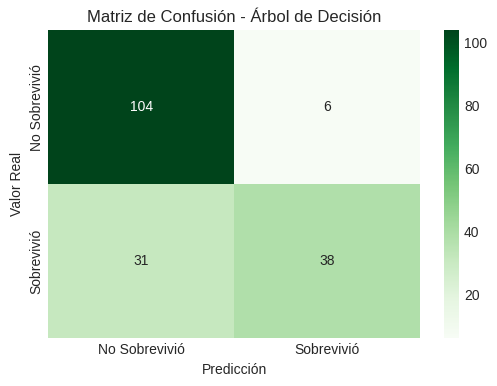

In [ ]:
# 1. Instanciar y entrenar el modelo de Árbol de Decisión
dec_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
dec_tree.fit(X_train, y_train)

# 2. Realizar predicciones
y_pred_dt = dec_tree.predict(X_test)

# 3. Evaluar el modelo
print("--- MÉTRICAS DE ÁRBOL DE DECISIÓN (CART) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_dt))

# Matriz de Confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['No Sobrevivió', 'Sobrevivió'], yticklabels=['No Sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

---
**Análisis de la Arquitectura: Visualización del Árbol de Decisión**

Para cumplir con la consigna de "explicar mediante reglas", se procede a la visualización de la arquitectura del modelo entrenado. Esta representación gráfica permite una auditoría completa del proceso de decisión del modelo, identificando las características más influyentes (aquellas más cercanas al nodo raíz) y las reglas específicas que conducen a cada predicción.

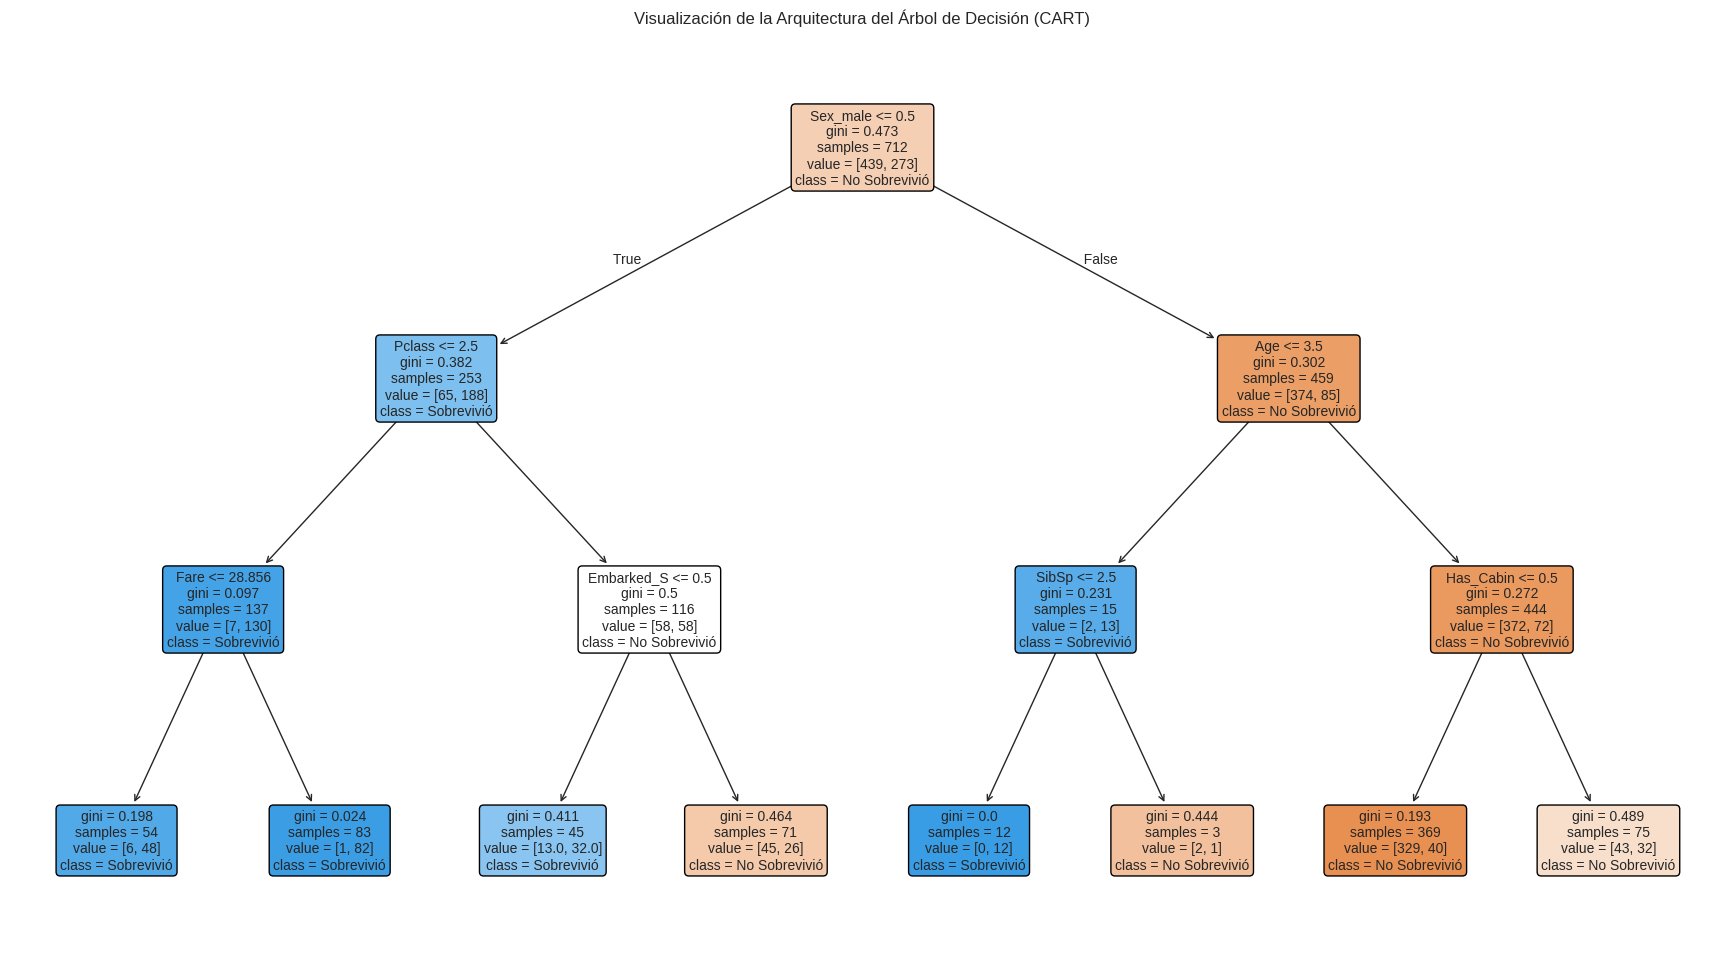

In [ ]:
plt.figure(figsize=(22,12))
tree.plot_tree(dec_tree, feature_names=X.columns, class_names=['No Sobrevivió', 'Sobrevivió'], filled=True, rounded=True, fontsize=10)
plt.title("Visualización de la Arquitectura del Árbol de Decisión (CART)")
plt.show()

---
#### **4.2. Modelo 2: Random Forest - Arquitectura de Ensamble**

**Fundamento Teórico:**
Random Forest es un método de aprendizaje por ensamble que opera construyendo una multitud de árboles de decisión durante el entrenamiento. En lugar de depender de un único estimador, agrega las predicciones de cada árbol para obtener una predicción final más robusta y precisa. Su eficacia se deriva de dos mecanismos fundamentales que promueven la diversidad entre los estimadores base:
1.  **Bootstrap Aggregating (Bagging):** Cada árbol se entrena sobre un subconjunto de datos muestreado con reemplazo (bootstrap sample) del conjunto de entrenamiento original.
2.  **Aleatoriedad de Características (Random Subspace Method):** En cada división de un nodo, solo se considera un subconjunto aleatorio del total de características, lo que decorrelaciona los árboles y reduce la varianza del modelo final.

**Hiperparámetros Clave:**
La configuración de un modelo Random Forest implica ajustar parámetros que gobiernan tanto el ensamble como sus componentes individuales:
*   `n_estimators`: Define el número de árboles (estimadores) en el bosque. Un valor mayor incrementa la robustez, aunque con un costo computacional creciente.
*   `max_depth`: Controla la profundidad máxima de cada árbol individual, actuando como un mecanismo de regularización para cada estimador.
*   `random_state`: Asegura la reproducibilidad de la construcción del ensamble, tanto en el proceso de bagging como en la selección de características.

--- MÉTRICAS DE RANDOM FOREST ---
Accuracy: 0.7877

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       110
           1       0.76      0.65      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



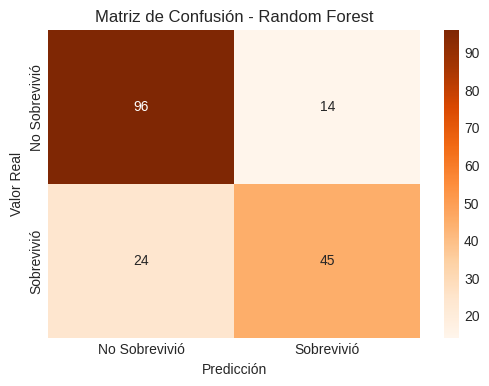

In [ ]:
# 1. Instanciar y entrenar el modelo de Random Forest
rand_forest = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rand_forest.fit(X_train, y_train)

# 2. Realizar predicciones
y_pred_rf = rand_forest.predict(X_test)

# 3. Evaluar el modelo
print("--- MÉTRICAS DE RANDOM FOREST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

# Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Sobrevivió', 'Sobrevivió'], yticklabels=['No Sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

---
### **Paso 5: Evaluación Comparativa de Modelos**

**Metodología de Comparación:**
Para realizar una comparación cuantitativa y objetiva del desempeño de ambos modelos, se utiliza la **Curva ROC (Receiver Operating Characteristic)** y el **Área Bajo la Curva (AUC)**. La curva ROC visualiza el rendimiento de un clasificador binario a través de todos los umbrales de clasificación, graficando la Tasa de Verdaderos Positivos (TPR o Recall) frente a la Tasa de Falsos Positivos (FPR). El AUC representa la probabilidad de que el modelo clasifique una instancia positiva aleatoria por encima de una instancia negativa aleatoria, proporcionando una métrica de rendimiento agregada e independiente del umbral.

**Generación de Probabilidades en Modelos Basados en Árboles:**
*   **CART:** La probabilidad predicha para una instancia es la proporción de muestras de la clase positiva presentes en el nodo hoja al que dicha instancia es asignada.
*   **Random Forest:** La probabilidad final es el promedio de las probabilidades predichas por cada uno de los árboles individuales que componen el ensamble.


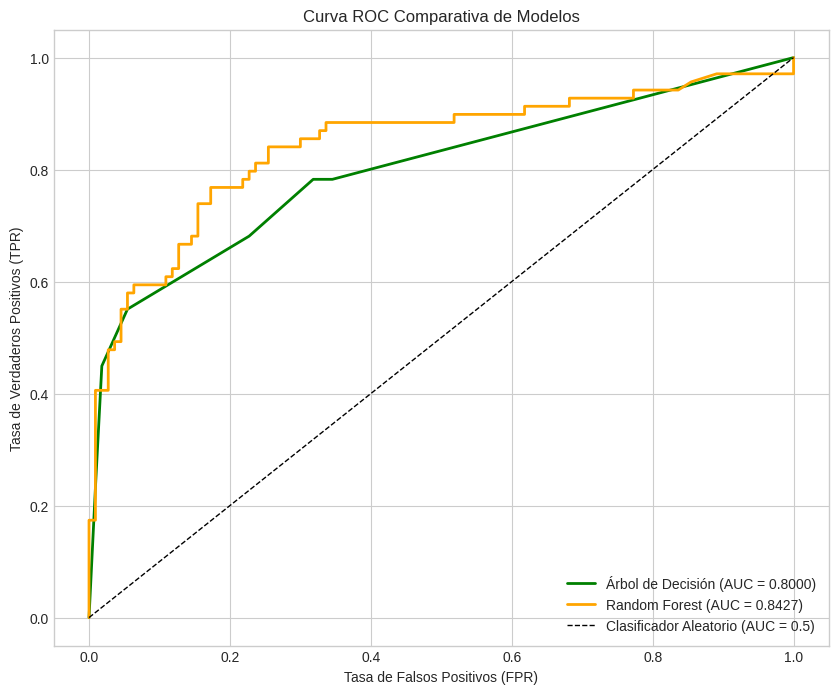


--- TABLA COMPARATIVA DE MÉTRICAS DE RENDIMIENTO ---


,Accuracy,Precision (Sobrevive),Recall (Sobrevive),F1-Score (Sobrevive),AUC
Modelo,,,,,
Árbol de Decisión,0.7933,0.8636,0.5507,0.6726,0.8000
Random Forest,0.7877,0.7627,0.6522,0.7031,0.8427


In [ ]:
# Calcular las probabilidades de la clase positiva para la curva ROC
y_prob_dt = dec_tree.predict_proba(X_test)[:, 1]
y_prob_rf = rand_forest.predict_proba(X_test)[:, 1]

# Calcular componentes de la curva ROC para cada modelo
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Graficar las curvas ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label=f'Árbol de Decisión (AUC = {auc_dt:.4f})', color='green', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='orange', lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5)', lw=1)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC Comparativa de Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Tabla comparativa de métricas
metrics_summary = {
    'Modelo': ['Árbol de Decisión', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    'Precision (Sobrevive)': [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    'Recall (Sobrevive)': [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)],
    'F1-Score (Sobrevive)': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)],
    'AUC': [auc_dt, auc_rf]
}
df_summary = pd.DataFrame(metrics_summary).set_index('Modelo')
print("\n--- TABLA COMPARATIVA DE MÉTRICAS DE RENDIMIENTO ---")
display(df_summary.style.format("{:.4f}"))

**Análisis Comparativo:**
Los resultados cuantitativos, tanto en la tabla de métricas como en el valor del AUC, indican una superioridad predictiva del modelo de Random Forest. Este rendimiento mejorado es atribuible a la reducción de la varianza lograda mediante el proceso de ensamble. Si bien el Árbol de Decisión individual ofrece una interpretabilidad total, el Random Forest sacrifica esta transparencia a cambio de una mayor capacidad de generalización y robustez, ejemplificando el clásico compromiso (trade-off) entre interpretabilidad y precisión en el aprendizaje automático.

---
### **Paso 6: Aspectos de Ética y Regulaciones**

Como lo solicita la consigna, es fundamental reflexionar sobre los aspectos éticos de los datos y algoritmos utilizados.

*   **Sesgos en los Datos:** El dataset del Titanic refleja los sesgos sociales de la época. El modelo aprende que el ser mujer o de primera clase aumenta la probabilidad de supervivencia. Si este modelo se usara para un propósito diferente, como asignar recursos de rescate en un escenario moderno, podría tomar decisiones discriminatorias e injustas, priorizando a ciertos grupos demográficos.
*   **Interpretabilidad de los Modelos:** Modelos como el Árbol de Decisión son "cajas blancas", es decir, podemos entender y explicar las reglas que utilizan para tomar decisiones. Esto es crucial para la transparencia y la rendición de cuentas. La Regresión Logística también es interpretable a través de sus coeficientes. El Random Forest, al ser un ensamble, es más una "caja negra", aunque se pueden extraer las importancias de las características.
*   **Palabras Clave:** `Sesgo (Bias)`, `Justicia (Fairness)`, `Interpretabilidad`, `Transparencia`, `Clasificación Supervisada`, `Datos Históricos`.

---
### **Paso 7: Conclusiones del Laboratorio**
  
El presente trabajo de laboratorio ha permitido ejecutar un ciclo completo de un proyecto de Ciencia de Datos, desde la exploración inicial hasta la evaluación comparativa de modelos. Las conclusiones principales son las siguientes:
1.  El **Análisis Exploratorio de Datos (EDA)** fue fundamental para identificar las variables con mayor poder predictivo, como el sexo, la clase socioeconómica y la edad.
2.  El **preprocesamiento de datos**, incluyendo la imputación de valores nulos y la codificación de variables categóricas, constituyó una etapa crítica para preparar el dataset para el modelado.
3.  Se implementaron y evaluaron dos arquitecturas de modelos: un **Árbol de Decisión (CART)**, que destacó por su total interpretabilidad, y un **Random Forest**, que demostró un rendimiento predictivo superior.
4.  La **evaluación cuantitativa**, mediante métricas como Accuracy, F1-Score y AUC, confirmó la mayor robustez del método de ensamble (Random Forest) para este problema de clasificación.
5.  Finalmente, se realizó una reflexión sobre las **implicaciones éticas**, destacando la presencia de sesgos en los datos y la importancia del compromiso entre la precisión del modelo y su capacidad de ser explicado.

------------ BORRABLE (TEORICO PARA ENTENDER) ----------------

## ¿De dónde sale la probabilidad *p* en los modelos de clasificación?

Cuando entrenamos un modelo de clasificación supervisada, no solo podemos obtener una predicción binaria (`0 = No`, `1 = Sí`), sino también una **probabilidad** `p` de que un ejemplo pertenezca a la clase positiva (`y=1`).  
El valor `p` depende del tipo de modelo y de cómo procesa las variables de entrada **X** (features).

---

### 🔹 1. Regresión Logística

La Regresión Logística es un **modelo lineal probabilístico**.  
El procedimiento es:

1. Se construye una combinación lineal de las variables de entrada:
   
$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n
$$

   donde:
   - $x_i$ son las variables predictoras (ej. edad, clase socioeconómica, sexo).  
   - $\beta_i$ son los coeficientes aprendidos durante el entrenamiento.

2. Se aplica la **función sigmoide** para convertir $z$ en un valor entre 0 y 1:

$$
p = \frac{1}{1 + e^{-z}}
$$

Esto asegura que el resultado pueda interpretarse como probabilidad.

**Ejemplo:**  
Si para un pasajero se obtiene $z = 1.2$, entonces:

$$
p = \frac{1}{1 + e^{-1.2}} \approx 0.77
$$

Es decir, el modelo estima un **77% de probabilidad de sobrevivir**.

---

### 🔹 2. Árbol de Decisión (CART)

Los árboles de decisión no calculan una fórmula matemática, sino que realizan **preguntas secuenciales** sobre las variables hasta llegar a una **hoja**.

- Cada hoja contiene un subconjunto de ejemplos del entrenamiento.  
- La probabilidad $p$ se calcula como la proporción de ejemplos positivos en esa hoja:

$$
p = \frac{\text{número de positivos en la hoja}}{\text{total de ejemplos en la hoja}}
$$

**Ejemplo:**  
Si en una hoja hay 20 pasajeros y 15 sobrevivieron, entonces:

$$
p = \frac{15}{20} = 0.75
$$

El modelo asigna **75% de probabilidad de sobrevivir** a cualquier pasajero que caiga en esa hoja.

---

### 🔹 3. Random Forest

El Random Forest es un **ensamble de muchos árboles de decisión**.  
Cada árbol individual calcula su probabilidad como se explicó antes.  
La probabilidad final es el **promedio de las probabilidades de todos los árboles**:

$$
p = \frac{1}{T} \sum_{t=1}^T p_t
$$

donde:
- $T$ = número total de árboles.  
- $p_t$ = probabilidad predicha por el árbol $t$.

**Ejemplo:**  
Si tenemos 3 árboles que predicen $p_1=0.8$, $p_2=0.6$, $p_3=0.9$, entonces:

$$
p = \frac{0.8 + 0.6 + 0.9}{3} = 0.77
$$

---

### 🔹 Conexión con la Curva ROC

La probabilidad `p` calculada por el modelo es lo que se usa para generar la **Curva ROC**:

- Si fijamos un umbral (ej. 0.5), se convierte `p` en una predicción binaria (0/1).  
- Para la curva ROC, en lugar de usar un solo umbral, se prueban **todos los umbrales posibles** (de 0 a 1).  
- En cada umbral se calculan:
  - **TPR (True Positive Rate)** = proporción de positivos reales bien detectados.  
  - **FPR (False Positive Rate)** = proporción de negativos reales mal clasificados como positivos.  

Así, la ROC muestra cómo cambia el desempeño del modelo según el umbral que elijamos.

---

✅ **En resumen:**  
- En regresión logística, `p` surge de una función sigmoide sobre una combinación lineal de las variables.  
- En árboles de decisión, `p` es la proporción de positivos en la hoja final.  
- En random forest, `p` es el promedio de las probabilidades de muchos árboles.  
- Estas probabilidades son la base para construir la curva ROC y medir el AUC.
